# Compute large circuits for NMR spectroscopy simulation using Fire Opal
**Simulate quantum Hamiltonian of liquid-state 1D NMR spectra**

Nuclear magnetic resonance (NMR) spectroscopy is a major analytical tool used to determine the structure of molecules, with broad applications in pharmaceutical research, material sciences, and biological studies. The quantum simulation of NMR spectra represents a promising use case for demonstrating quantum utility, as there is a direct correspondence between the quantum dynamics of nuclear spin systems and their simulation on quantum computers.

This application note based on [Burov et al. (2025)](https://arxiv.org/abs/2512.14513) demonstrates how [Fire Opal's error suppression and mitigation pipeline](https://docs.q-ctrl.com/fire-opal) enables the execution of deep quantum circuits for NMR spectroscopy simulations, achieving:

- Up to $22×$ improvement in mean square error (MSE) compared to default hardware output
- Successful simulation of spin systems with up to 34 spins
- Circuit depth reduction of $28\%-51\%$ through optimized transpilation
- Cross-platform execution on IBM Quantum and IonQ quantum hardware

## 1. Introduction

### 1.1 NMR Hamiltonian

NMR spectroscopy provides detailed information about molecular structure through the interaction of nuclear spins with magnetic fields. The numerical simulation of NMR experiments is computationally challenging on classical computers because the required resources grow exponentially with the size of the spin system. Quantum computers offer a natural approach to this problem: each nuclear spin maps directly to a qubit, and the Heisenberg Hamiltonian governing NMR dynamics is expressed in terms of Pauli operators, the same building blocks as quantum circuits. However, the depth of quantum circuits required for accurate Hamiltonian simulation makes these computations highly susceptible to noise.

High-field liquid NMR is nuclear magnetic resonance spectroscopy of samples in solution using a very strong, highly uniform magnetic field, typically produced by a superconducting magnet. For liquid-state NMR with spin $\frac{1}{2}$ nuclei, the full laboratory-frame Hamiltonian is a sum of Zeeman interactions, in which nuclear spins couple to the external field $B_0$; chemical shift effects, from shielding by local electron clouds; and scalar J-coupling, an indirect spin-spin interaction mediated by electrons. Because the Zeeman terms are by far the largest, it is standard practice to move into a rotating frame at the reference frequency of the observed nucleus species $S$. In this frame the large Zeeman terms subtract out, and what remains is the offset Hamiltonian: 

$$H_{\text{rot}} = \sum_{k=1}^{N} \omega_k I_k^z + 2\pi \sum_{k<l} J_{kl} \, \vec{I}_k \cdot \vec{I}_l$$

where:
- $\omega_k$ is the chemical-shift-induced offset of spin $k$
- $J_{kl}$ is the spin-spin coupling constant between spins $k$ and $l$
- $\vec{I}_k = (I_k^x, I_k^y, I_k^z)$ are the spin operators, related to Pauli operators by $\hat{I}_{x,y,z} = \frac{1}{2}\hat{\sigma}_{x,y,z}$

The full isotropic coupling $\vec{I}_k \cdot \vec{I}_l = I_k^X I_l^X + I_k^Y I_l^Y + I_k^Z I_l^Z$ is retained without the secular approximation, meaning the $XX$ and $YY$ coupling terms are not dropped, which is important for capturing strong coupling effects in classically hard spin systems.

## 1.2 Quantum Simulation

You can simulate the spectrum by sampling the free induction decay (FID), the time-dependent transverse magnetization after an effective excitation. You first prepare the transverse state $|\psi_0\rangle = |+\rangle^{\otimes N}$, evolve it under the rotating-frame Hamiltonian, measure transverse magnetization, and calculate the Fourier transform from the resulting time trace.

### 1.2.1 The Initial State and the Deviation Density Matrix

In a real NMR experiment, the equilibrium state at high field is almost maximally mixed, with a tiny polarization along $B_0$. The FID signal is linear in the small deviation from the identity, so you can ignore the identity part and simulate only the deviation density operator. This is represented by the pure transverse magnetization state:

$$|\psi_0\rangle = |+\rangle^{\otimes N} = \left(\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right)^{\otimes N}$$

This is the zero-temperature limit of a $\pi/2$ pulse that rotates the equilibrium polarization from $z$ into the transverse plane. It is prepared on a quantum computer with a single layer of Hadamard gates.

The observable you track is the transverse magnetization for observed spin species $S$:

$$M_X^S(t) = \langle \psi(t) | \sum_{j \in S} I_j^X | \psi(t) \rangle, \quad M_Y^S(t) = \langle \psi(t) | \sum_{j \in S} I_j^Y | \psi(t) \rangle$$

Together these form the complex FID signal $S(t) = M_X^S(t) + i M_Y^S(t)$. Taking the Fourier transform of $S(t)$ over the $K$ time points gives the frequency-domain 1D NMR spectrum.

### 1.2.2 Encoding Time Evolution as a Quantum Circuit

The time evolution operator $e^{-i H_{\text{rot}} t}$ cannot be implemented directly on a quantum computer as the Hamiltonian has many non-commuting terms. Instead, you can use Trotterization:

$$|\psi(t)\rangle = e^{-i H_{\text{rot}} t} |\psi_0\rangle \approx \prod_j e^{-i H_j t} |\psi_0\rangle$$

where the $H_j$ are the individual Hamiltonian terms (chemical shift terms and pairwise $J$-coupling terms). Each exponential $e^{-i H_j t}$ maps to one or two quantum gates. The one-qubit terms $e^{-i \omega_k I_k^z t}$ are single-qubit $R_z$ rotations. The two-qubit coupling terms $e^{-i 2\pi J_{kl} \vec{I}_k \cdot \vec{I}_l t}$ each decompose into a sequence of $CNOT$ or $CZ$ gates and single-qubit rotations. In this example, each time point $t$ is encoded with a single Trotterized circuit. 



## 2. The Computation Pipeline

Figure 1 shows the complete workflow. You start from the spin system matrix of the molecule — an $N \times N$ array whose diagonal entries are chemical shifts in ppm and off-diagonal entries are J-couplings in Hz. From this you construct $H_{\text{rot}}$, generate a parametrized quantum circuit encoding one Trotter step of the time evolution, and instantiate that template $K$ times by substituting each time value $t_k$. Those circuits pass through the Fire Opal pipeline, execute on hardware, and the measured expectation values of $M_X^S$ and $M_Y^S$ are assembled into the complex FID. A final zero-padded FFT with frequency rescaling to ppm produces the 1D spectrum.

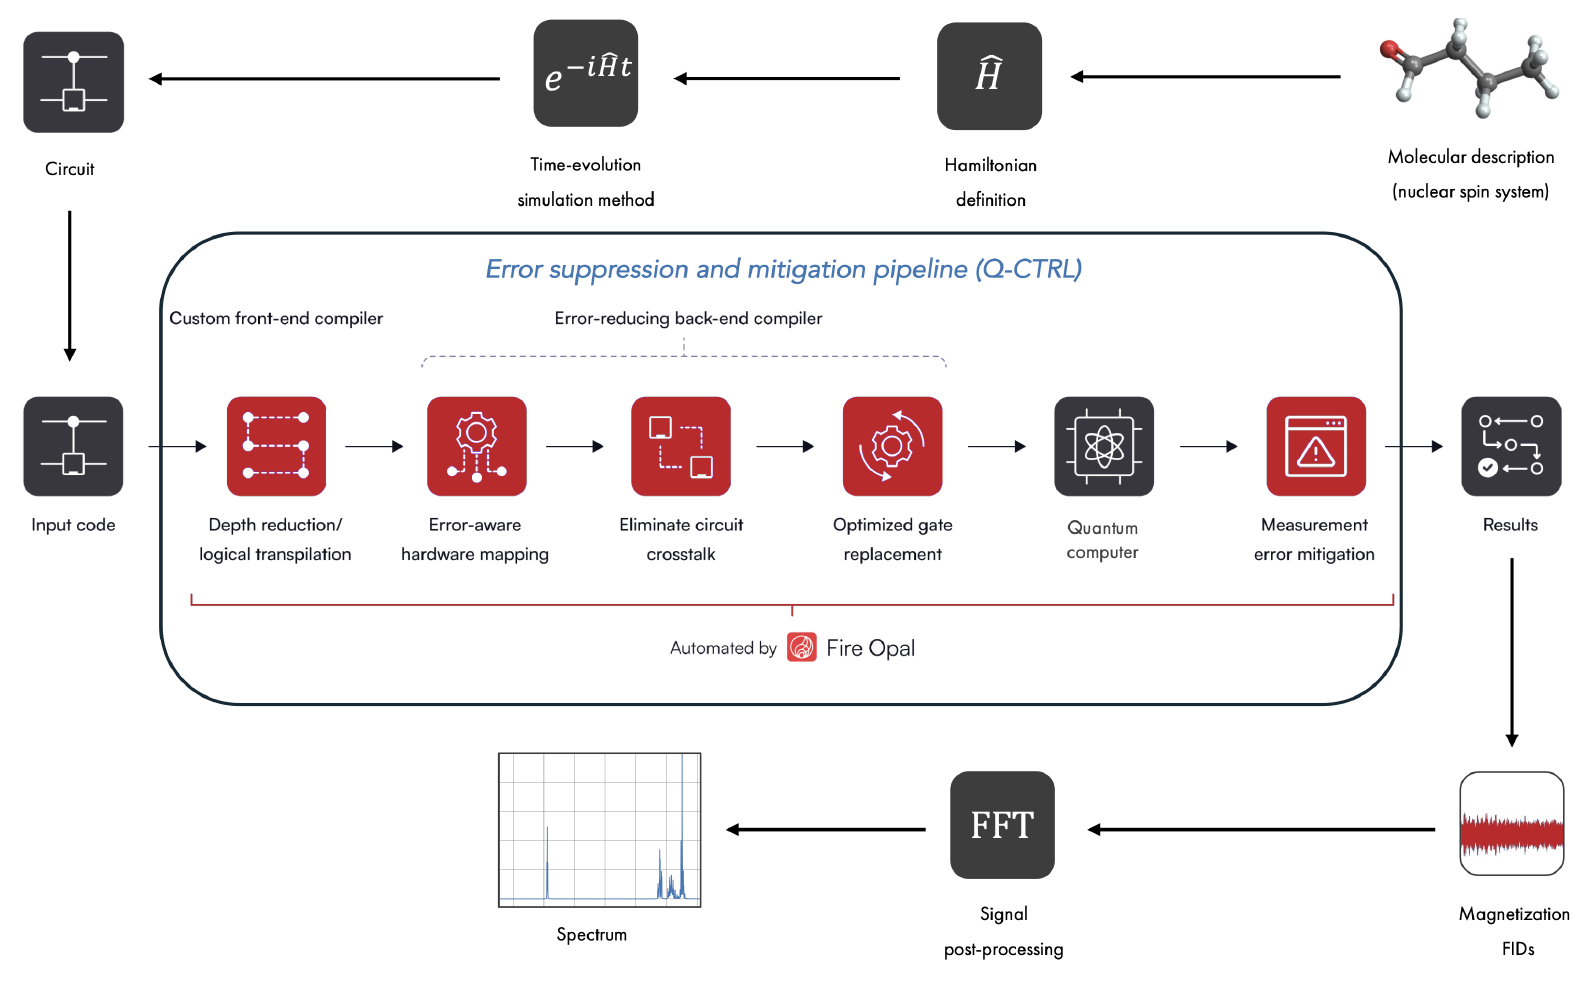
Figure 1: The complete computation pipeline, from molecular description through quantum circuit execution to 1D NMR spectrum. 

## 3. Spin Systems Under Study

Four molecules were selected from the SPINACH example library specifically because they represent systems where classical simulation is difficult or intractable. All four share a useful property for quantum simulation: each nuclear spin maps exactly to one qubit with no encoding overhead, so the number of qubits required equals the number of spins in the molecule.

The smallest system is anti-3,4-difluoroheptane (DFH), with 16 spins and $^{19}$F as the observed nucleus. The two inequivalent fluorine atoms resonate at approximately $-184$ ppm and are connected to the surrounding hydrogen network through a dense set of F–H J-couplings spanning several bonds. It is this coupling network, rather than the spin count alone, that makes DFH a hard simulation target: the off-diagonal Hamiltonian terms mix states across the full Hilbert space, preventing the block-diagonal simplifications that make weakly coupled systems tractable classically.

The symmetric P–H molecule with two tert-butyl groups contributes two separate simulations at 22 spins, one observing the 20 proton spins and one observing the 2 phosphorous spins. The two phosphorous atoms are directly bonded and strongly coupled to each other ($J_{\text{PP}} = 301.99$ Hz), while each phosphorous is further coupled to 9 equivalent methyl protons ($J_{\text{PH}} = 15.63$ Hz). This combination of a large homonuclear coupling alongside many weaker heteronuclear couplings produces multiplet structure in both the $^{1}$H and $^{31}$P spectra that requires resolving many closely spaced transitions. The proton simulation (symm_H) and the phosphorous simulation (symm_P) probe different aspects of the same spin system and appear together throughout the results.

The B[ACR9]$_3$ phosphorous cluster at 34 spins is the centerpiece of the paper. It sits just beyond the practical Liouville limit of 32 spins, the point at which representing the full density matrix as a $2^N \times 2^N$ object becomes memory-intractable on classical hardware without approximation. The 7 phosphorous atoms span a wide chemical shift range from $-0.33$ to $-156.7$ ppm and are interconnected by a dense network of P–P couplings, the strongest reaching $-354.82$ Hz. The classical SPINACH benchmark requires a coherence-order truncation to make the state space manageable, plus GPU resources and several hours of compute time. A quantum computer sidesteps the memory wall entirely: 34 qubits hold the full state exactly, and the simulation cost scales with circuit depth rather than Hilbert space dimension.

## 4. Fire Opal Error Suppression and Mitigation

At the circuit depths required for these simulations, raw hardware output is dominated by decoherence and gate errors rather than the NMR physics you intended to compute. Fire Opal addresses this issue through a five-stage pipeline applied automatically to every circuit.

- **Logical transpilation** compiles each circuit to the device's native gate set and applies mathematical gate combinations to merge or cancel redundant operations before any hardware-specific step. On IBM hardware this targets the CZ gate; on IonQ Forte Enterprise it targets the Mølmer–Sørensen gate.
- **Error-aware hardware mapping** assigns logical qubits to physical qubits using real-time calibration data, prioritising qubits with lower error rates and qubit pairs that minimise cross-talk. On a 156-qubit chip like `ibm_aachen` there is substantial variation across the device, so this selection is consequential.
- **Dynamical decoupling** inserts carefully timed single-qubit pulse sequences into idle periods to suppress dephasing ($T_2$ errors) and ZZ cross-talk between neighboring qubits. These spin-echo sequences add to the one-qubit gate count — which is why the optimized circuits contain *more* single-qubit gates than the raw compilations — but they actively cancel dephasing noise that would otherwise wash out the FID.
- **Optimized gate replacement** consolidates blocks of adjacent two-qubit gates and resynthesizes them using the minimum number of native entangling gates, followed by a similar pass over single-qubit gate sequences.
- **Measurement error mitigation** corrects bit-flip and readout errors after execution using a sublinear-scaling confusion matrix approach. Fire Opal partitions the device into small qubit groups, builds a confusion matrix for each, and applies the combined correction to the output distributions.

Figure 2 shows the combined effect on circuit depth across all time points for each spin system.

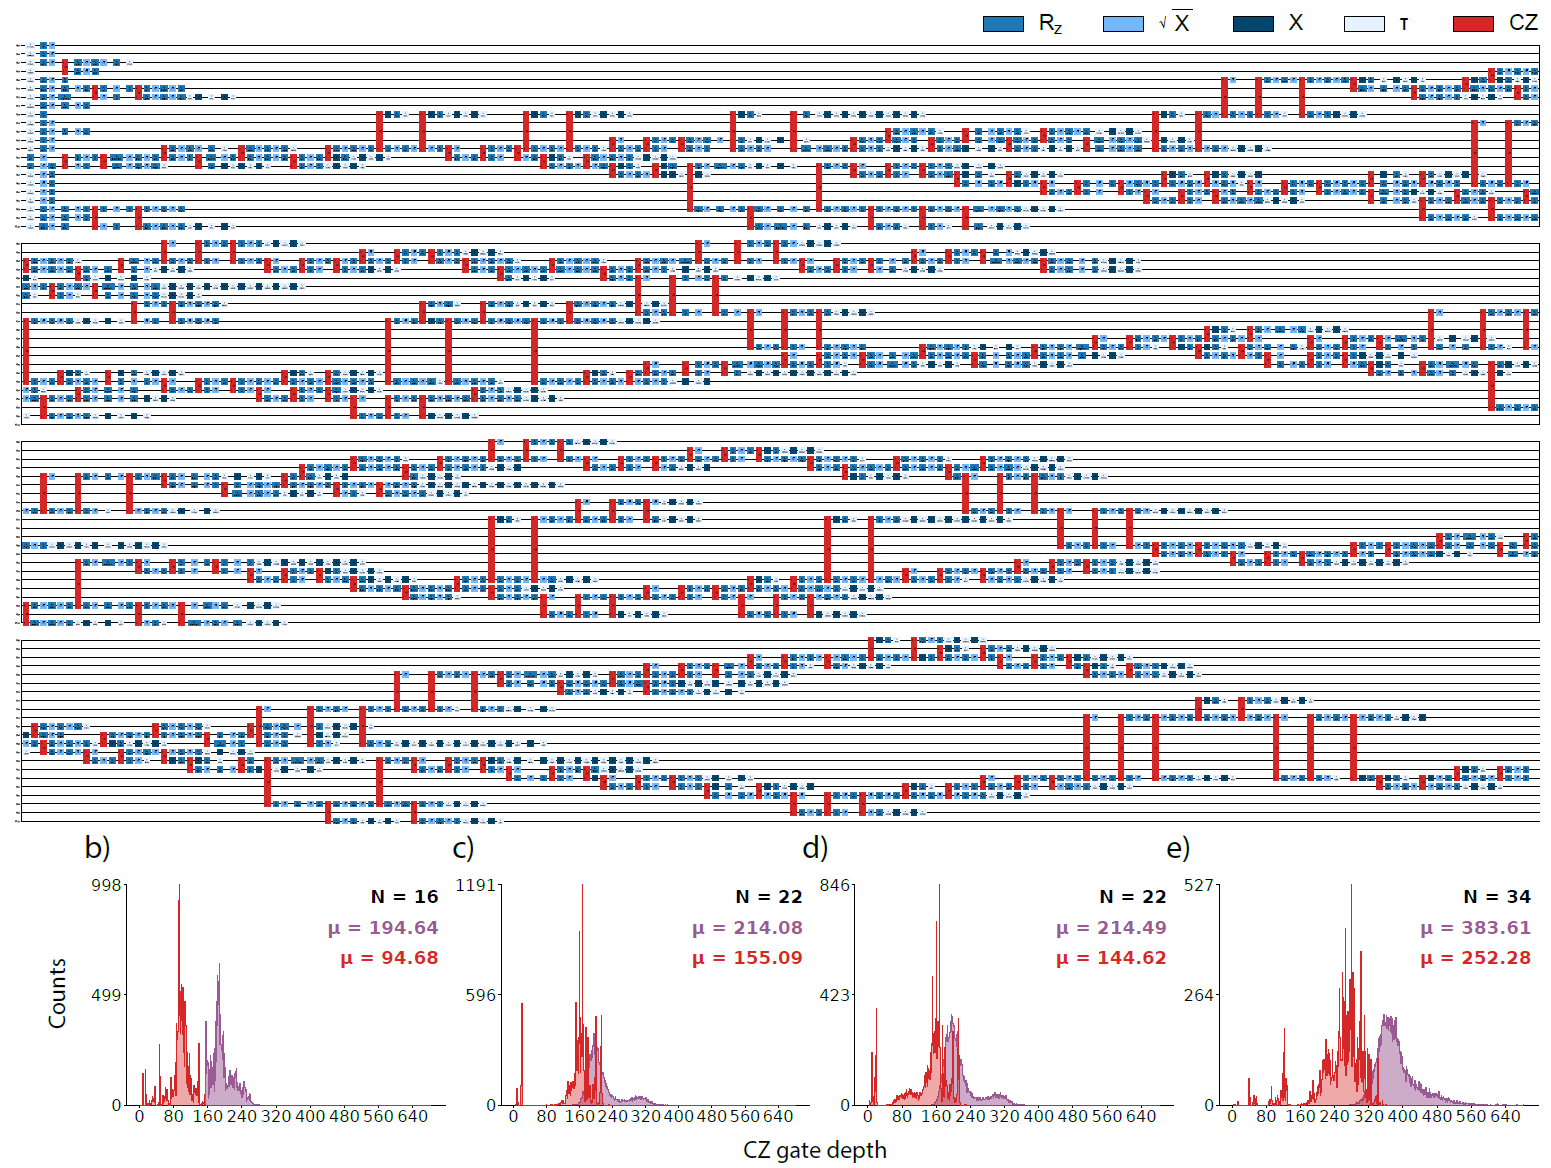

Figure 2: Distributions of CZ gate depth across all $K$ time points. Magenta: raw IBM compilation. Red: Fire Opal-optimized. Depth reductions are 51% for DFH, 28–32% for the 22-spin systems, and 34% for the phosphorous cluster. The wider spread of the Fire Opal distributions reflects per-circuit optimisation, layout mapping, dynamical decoupling, and gate resynthesis all adapt independently to each circuit rather than being applied uniformly. 

## 5. Results

### 5.1 FID Signal Quality

The $^1$H FID for symm_H provides a clear test of what the pipeline gains in practice. At $22$ spins and $8,192$ shots per time point, it is large enough that raw hardware noise is substantial but small enough that a noiseless reference can be computed exactly for comparison. Without Fire Opal, the hardware output (magenta in Figure 3) tracks the noiseless oscillation for roughly the first $50$ time points before decoherence overwhelms the signal by $t = 400\Delta t$ the trace is indistinguishable from noise. The cosine similarity with the noiseless reference is $0.511$, and the MSE over all $800$ time points is $45.977$.

With Fire Opal (red), the FID follows the noiseless dynamics faithfully through the first $240$ time points, where the oscillation amplitude is largest and the spectral information is most concentrated, and remains qualitatively correct across the full trace. The cosine similarity rises to $0.985$ and the MSE drops to $3.698$, a factor of $12$ improvement overall, and $22×$ over the first $240$ points. 

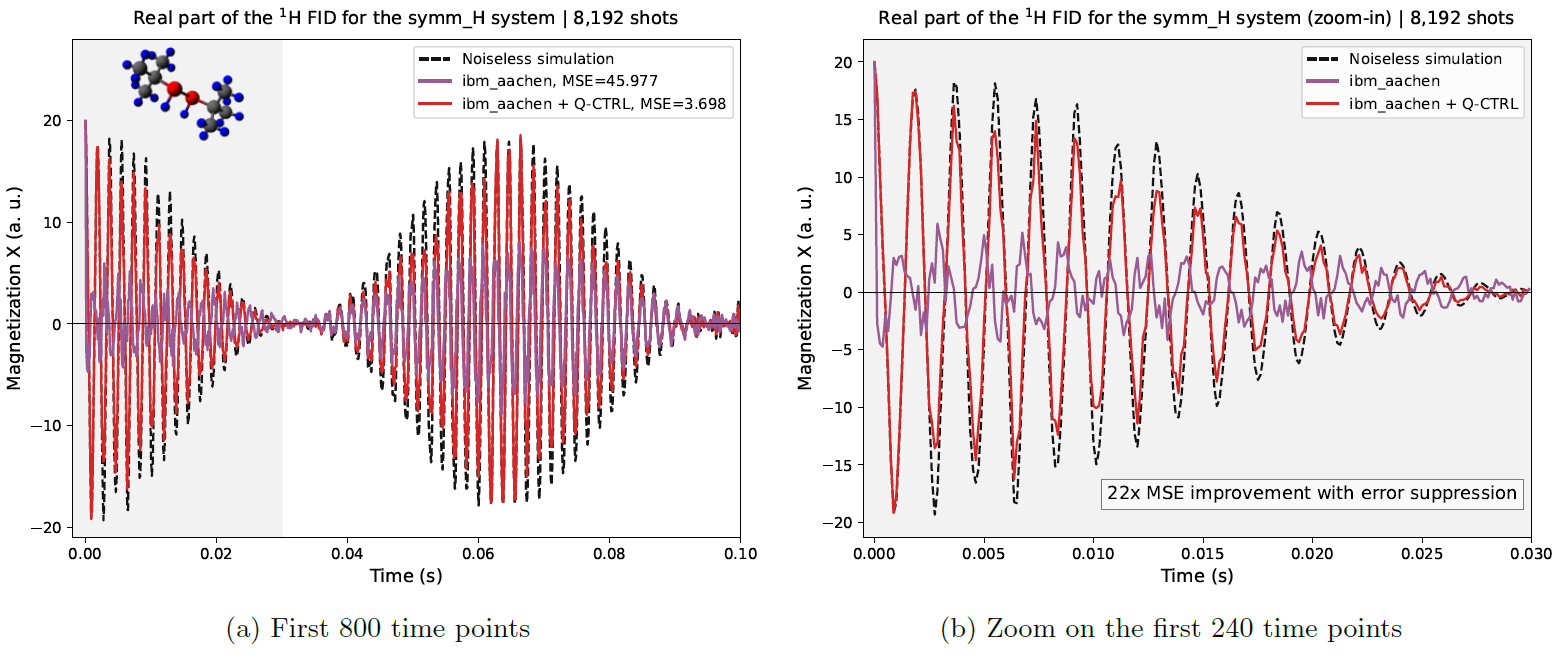

Figure 3: Real part of the $^1$H FID for symm_H. Dashed black: noiseless simulation. Solid magenta: raw `ibm_aachen`. Solid red: `ibm_aachen` with Fire Opal. Left: full 800-point trace. Right: zoom on the first 240 time points.

### 5.2 1D NMR Spectra

The FID signals are converted to spectra by zero-padding and applying an FFT, with the frequency axis rescaled to ppm using the spectrometer frequency of the observed nucleus. Figure 4 shows all four results on `ibm_aachen` with Fire Opal, alongside the SPINACH classical reference computed within the grey region of interest.

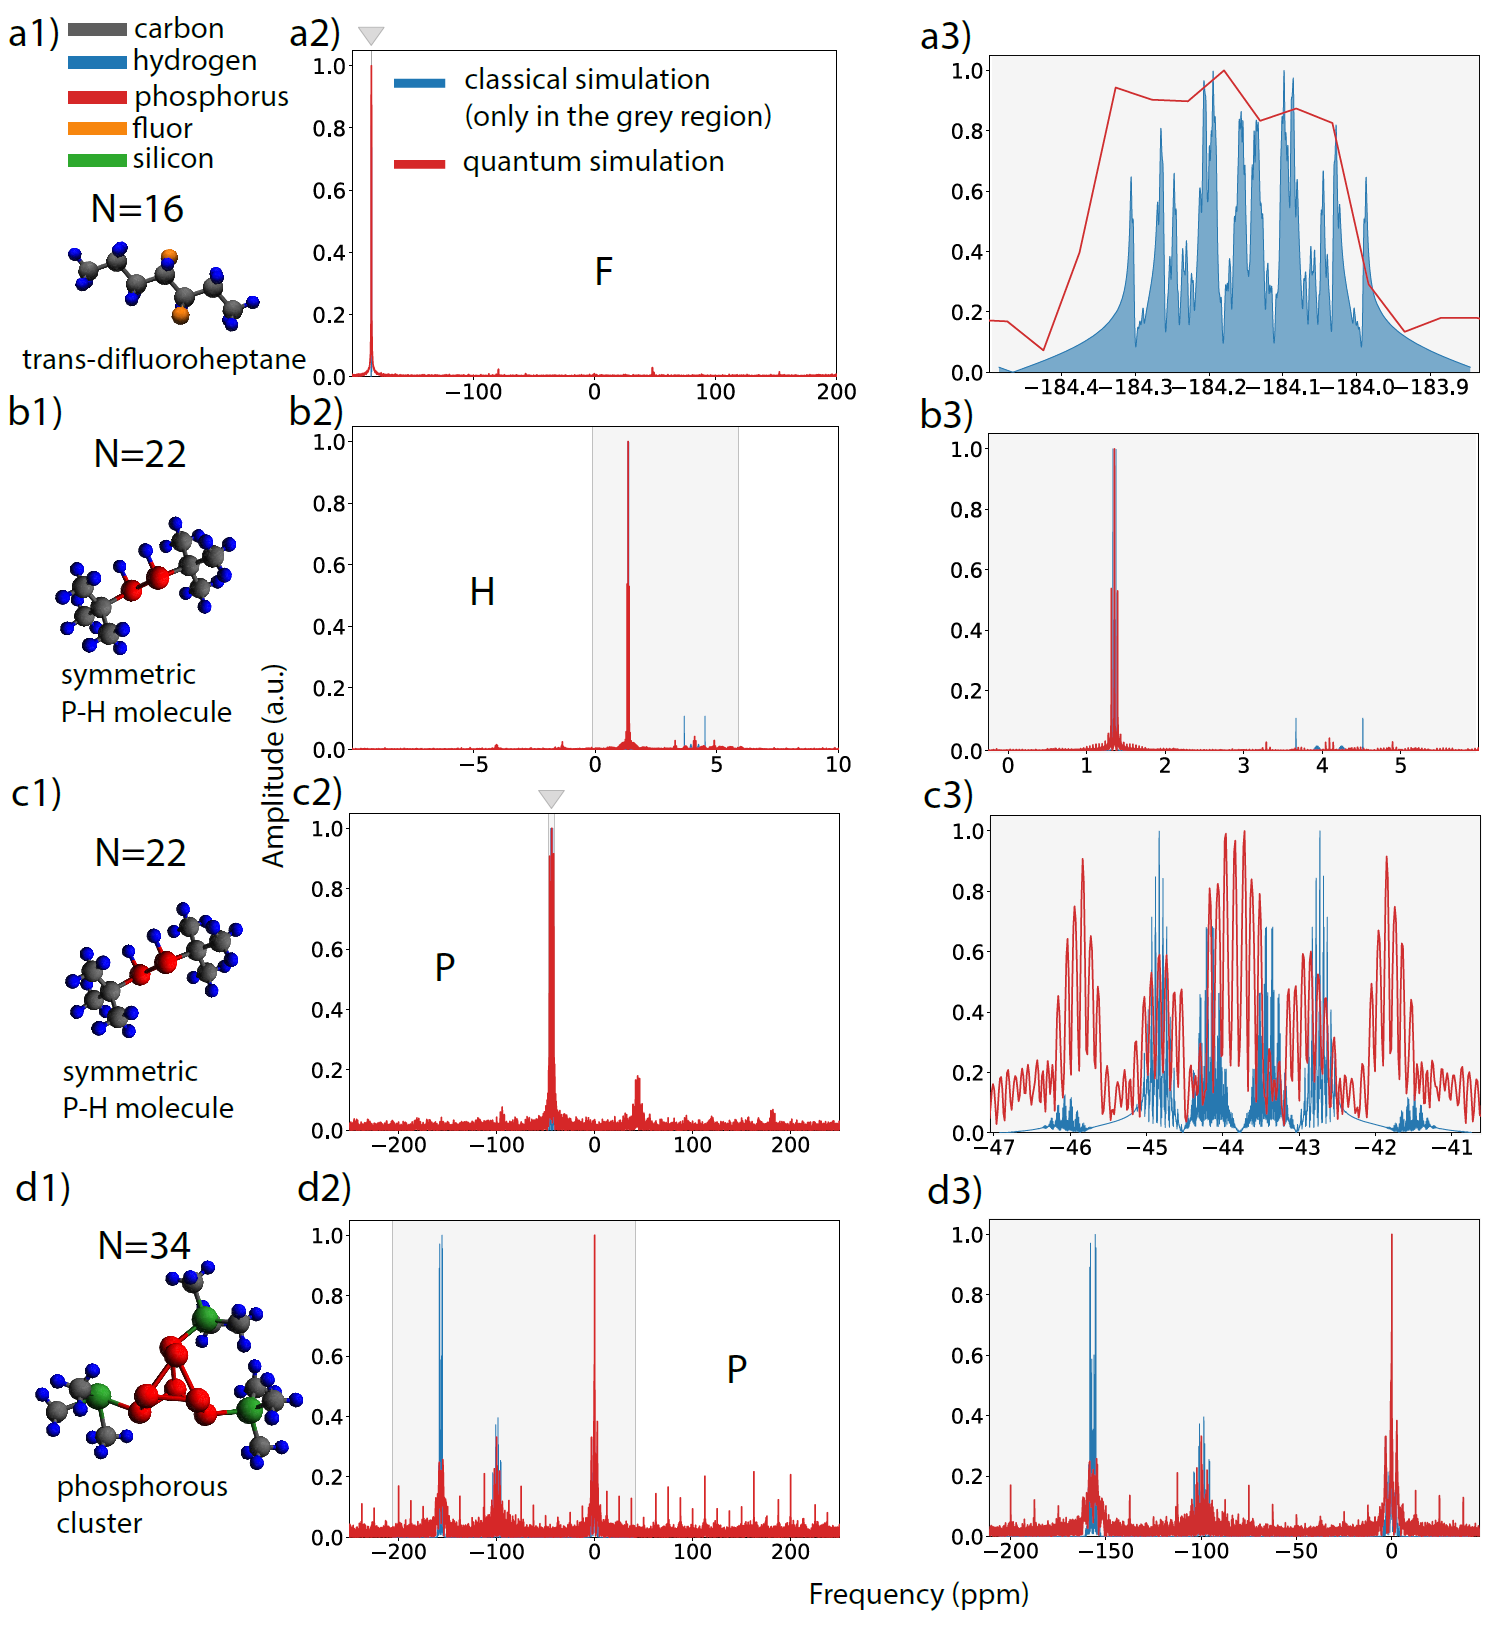

Figure 4: 1D NMR spectra for all four spin systems. Column 1: molecular structures. Column 2: full frequency range. Column 3: zoom on the region of interest. Red: quantum simulation on `ibm_aachen` with Fire Opal. Blue: SPINACH classical reference. 

The DFH $^{19}$F spectrum shows both fluorine peaks at approximately $-184$ ppm with correct relative positions. The zoom panel reveals the beginning of multiplet substructure from the F–H coupling network, though full resolution of the individual lines would require more than one Trotter step. The symm_H $^1$H spectrum cleanly reproduces the dominant tert-butyl proton peak and the secondary cluster near 4 ppm, both at the correct chemical shifts.

The symm_P $^{31}$P result is the most informative in terms of the method's current limitations. The main peak position is reproduced, but the fine structure arising from the $301.99$ Hz P–P coupling, which should split the peak into a doublet with well-resolved components, appears as a broadened and distorted feature. This distortion is not caused by hardware noise: as shown in Section 5.4, the hardware output is nearly identical to the noiseless circuit simulation. The distortion comes entirely from the one-step Trotter approximation, which does not evolve the strongly coupled P–P spin pair accurately enough to produce the correct splitting.

The phosphorous cluster at $34$ spins is the most significant result. The main peaks across the $-200$ to $0$ ppm range are correctly positioned and match the SPINACH reference in the zoom panel, including an indication of the underlying substructure. This is the first simulation of a $34$-spin NMR system on quantum hardware a system that sits beyond the practical Liouville limit and that no classical method can simulate exactly without approximation.

### 5.3 Cross-Platform Comparison: IBM vs. IonQ

The symm_P $^{31}$P spectrum was run on both `ibm_aachen` and IonQ Forte Enterprise to understand how the different hardware modalities handle the same simulation under Fire Opal. The two platforms represent opposite engineering tradeoffs: IBM's superconducting qubits operate at nanosecond gate speeds on a fixed heavy-hex lattice, while IonQ's trapped-ion qubits have microsecond gate speeds but all-to-all connectivity and coherence times orders of magnitude longer.

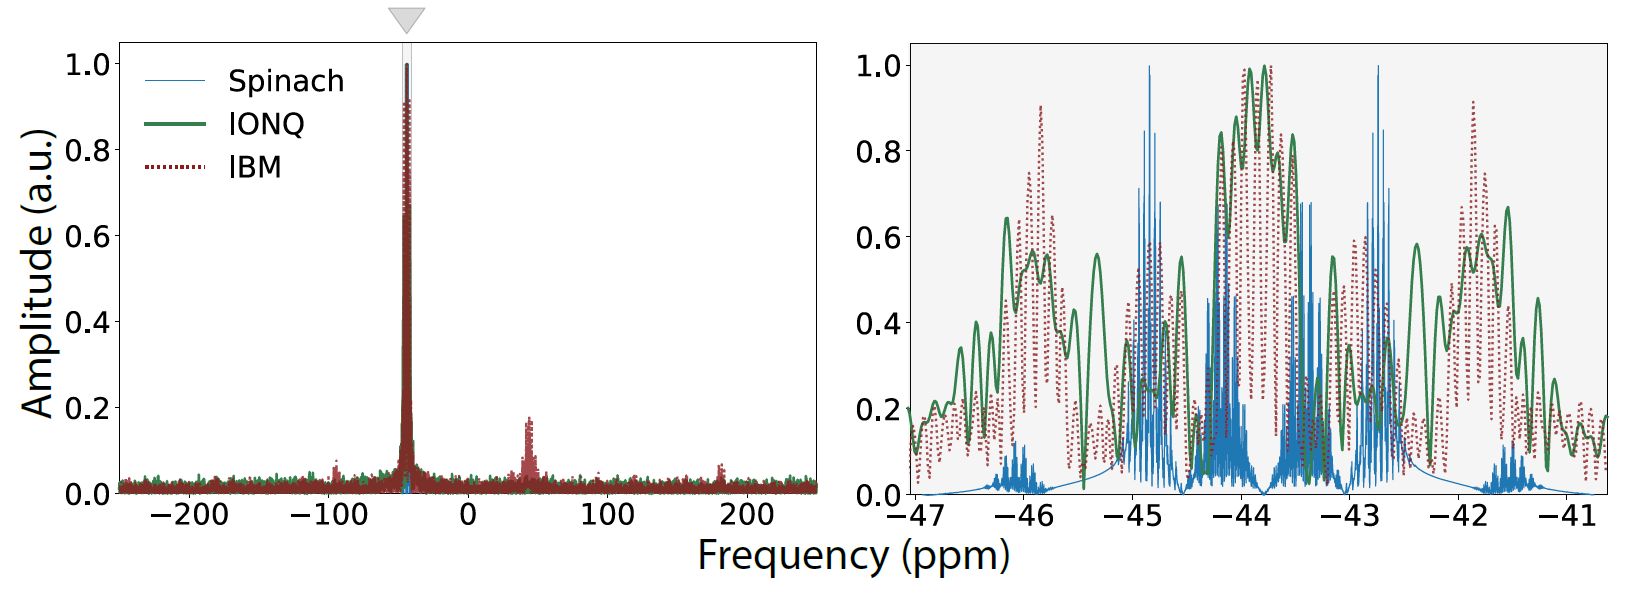

Figure 5: symm_P $^{31}$P spectrum on IBM `ibm_aachen` with Fire Opal (dotted red) and IonQ Forte Enterprise (solid green) vs. SPINACH classical reference (solid blue). Left: full ppm range. Right: zoom on the region of interest. Figure from Burov et al. (2025).

Both platforms reproduce the correct peak positions in the region of interest. The qualitative difference is the circuit depth, on `ibm_aachen`, Fire Opal reduces the two-qubit depth to $145 ± 49$ layers (32% improvement). On IonQ, the all-to-all connectivity eliminates the SWAP routing overhead that the heavy-hex lattice requires for long-range J-couplings, and the effective two-qubit depth falls to $36$. Shallower circuits accumulate less error even before any mitigation is applied.

| Parameter | IBM `ibm_aachen` | IonQ Forte Enterprise |
|---|---|---|
| Technology | Superconducting (Heron chip) | Trapped-ion ($^{171}$Yb$^+$) |
| Connectivity | Heavy-hex lattice | All-to-all |
| $T_2$ coherence | $~179 ± 8$ μs | ~$9.5 \times 10^5$ μs |
| Two-qubit gate time | $68$ ns | $650$ μs |
| Two-qubit gate error rate | $1.91 ± 0.02 \times 10^{-3}$ | $7.66 \times 10^{-3}$ |
| Optimized 2Q depth (symm_P) | $145 ± 49$ | $36$ ($69$ effective) |
| Total QPU time (symm_P) | $5$ h $20$ min | $105$ h $59$ min |

The practical cost of IonQ's longer coherence and lower depth is throughput. IBM's gates are roughly $10,000×$ faster, which is why the IBM runtime is $~20×$ shorter despite using a larger shot budget ($4,096$ vs. $700$ shots per time point). The IonQ shot count of $700$ was not chosen arbitrarily: the authors ran $20$ randomly selected time points at shot counts from $100$ to $2,000$ and tracked the MSE against the noiseless reference. The error plateaus at approximately $700$ shots, at which point additional shots provide no further benefit because circuit error is already the dominant term.

### 5.4 Algorithmic Error vs. Hardware Noise

You can separate the total error into two independent contributions: hardware noise (decoherence, gate errors, readout) and algorithmic error (Trotterization). Fire Opal handles the first; the second is intrinsic to the simulation method. Comparing the Fire Opal output for symm_H against both references simultaneously tells you which term dominates.

| Comparison | MSE | Cosine similarity |
|---|---|---|
| Fire Opal hardware vs. noiseless circuit simulation | $8.06 \times 10^{-5}$ | 0.9011 |
| Fire Opal hardware vs. SPINACH physical reference | $1.09 \times 10^{-3}$ | 0.3596 |

The hardware output with Fire Opal is nearly indistinguishable from what a perfect, noiseless version of the same Trotterized circuits would produce. The gap to the SPINACH reference is $13×$ larger and comes entirely from the one-step product formula not accurately representing the true time evolution of the strongly coupled spin system. 

## 6. Discussion and Conclusion

In this work Fire Opal has suppressed hardware noise below the level of the Trotterization error, shifting the bottleneck from the device to the algorithm. A single product formula step introduces phase errors of order $O(t^2 \|[H_i, H_j]\|)$, and for molecules with large J-couplings the commutator norms are large enough to distort multiplet substructure, as the symm_P $^{31}$P result demonstrates. 

Several algorithmic paths can address this bottleneck without waiting for better hardware. Spin echo techniques developed specifically for NMR Hamiltonians exploit the structure of the Heisenberg coupling terms to achieve dramatically shorter circuits, potentially fitting multiple effective Trotter steps within the same gate budget used here for one. Higher-order product formulas reduce error per step at moderate depth cost and are straightforward to implement within the existing framework. Qubitization eliminates Trotter error entirely in principle, with optimal $O(t + \log(1/\varepsilon))$ depth scaling, though it has not yet been demonstrated for NMR simulation on hardware. Each of these techniques, combined with the Fire Opal pipeline demonstrated here, is a concrete path to spectra that resolve the full multiplet substructure, the threshold at which quantum NMR simulation becomes genuinely useful to a practicing chemist.
